<a href="https://colab.research.google.com/github/rlogger/ErrP/blob/main/MI_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install mne pyriemann

In [16]:
import numpy as np
import random
seed = 42
random.seed(seed)
np.random.seed(seed)

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from pathlib import Path

# Corrected path with a single 'data/' directory
directory_path = Path('/content/drive/MyDrive/data/Mi Game')
data_files = [str(file_path.resolve()) for file_path in directory_path.rglob('*.edf')]

print(data_files)
print(len(data_files))

['/content/drive/MyDrive/data/Mi Game/2026_03_06_mi_0001_raw.edf', '/content/drive/MyDrive/data/Mi Game/03_09_26_mi_churek_raw.edf', '/content/drive/MyDrive/data/Mi Game/03_09_26_mi_omer_raw.edf', '/content/drive/MyDrive/data/Mi Game/04_6_26_andy_mi_raw.edf']
4


In [19]:
event_id = {
  "left": 1,
  "right": 2,
}

In [20]:
import mne
import numpy as np

def load_raw_edf(edf_file_path):
  data = mne.io.read_raw_edf(edf_file_path, preload = True)
  print(data.info)
  print(f"Original channel names: {data.info.ch_names}")

  ### Reference to Left Ear channel, default is Pz ###
  data.set_eeg_reference(ref_channels=['EEG LE-Pz'])

  ### Standardize channel names ###
  rename_dict = {}
  for ch_name in data.ch_names:
      if '-Pz' in ch_name:
          rename_dict[ch_name] = ch_name.replace('-Pz', '')
      if ch_name == "Pz":
          rename_dict[ch_name] = "EEG Pz"
  data.rename_channels(rename_dict)
  print(f"Updated channel names: {data.info.ch_names}")

  ### Preprocess with bandpass ###
  data.filter(l_freq=8.0, h_freq=30.0, picks="eeg")

  ### Find events labeled in the Trigger column ###
  events = mne.find_events(data, stim_channel='Trigger', min_duration=0.0)
  print(f'Found {len(events)} events')
  print(f'Event IDs: {set(events[:, 2])}')
  print(f"Event Counts: {mne.count_events(events)}")
  ### Create epochs time locked to the event triggers ###
  epochs = mne.Epochs(
      data,
      events,
      event_id=event_id,
      tmin=0.0,      # Start 200 ms before event
      tmax=3.0,       # End 800 ms after event
      baseline=(0.0, 0.0),  # Baseline period for correction
      preload=True
  )
  channels = ['EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz']
  epochs = epochs.pick(channels)

  ### Plot epochs ###
  evokeds = [epochs[cond].average() for cond in list(event_id.keys())]
  mne.viz.plot_compare_evokeds(evokeds)

  ### Convert epochs and event labels to numpy ###
  samples = []
  labels = []
  for key in event_id.keys():
        datum = epochs[key].get_data()[:,:,:-1]
        samples.append(datum)
        labels.extend([key]*datum.shape[0])
  X = np.concatenate(samples, axis=0)
  y = np.array(labels)

  return X, y



Loading file #1/4
Extracting EDF parameters from /content/drive/MyDrive/data/Mi Game/2026_03_06_mi_0001_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 291599  =      0.000 ...   971.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-06 15:12:18 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
Filtering raw d

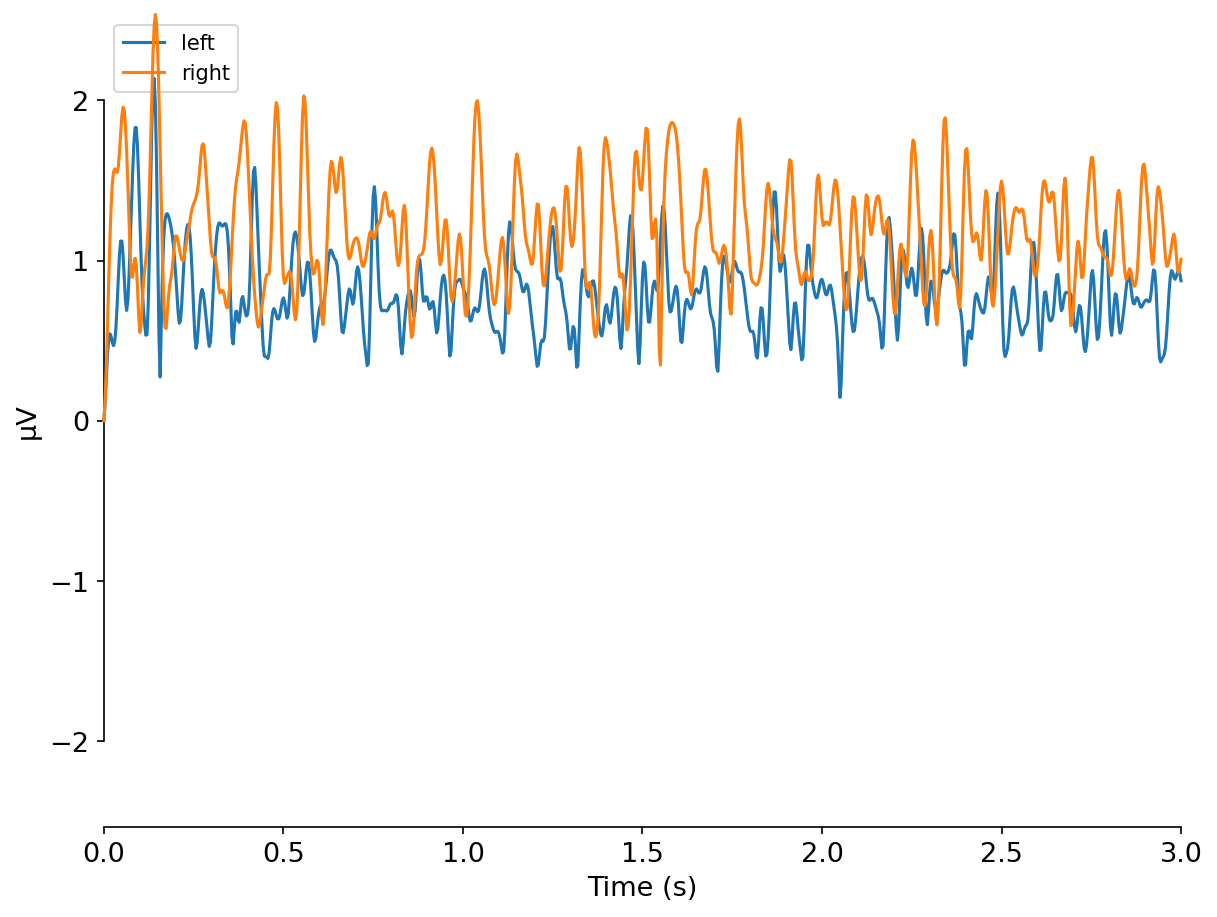

Loading file #2/4
Extracting EDF parameters from /content/drive/MyDrive/data/Mi Game/03_09_26_mi_churek_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 296999  =      0.000 ...   989.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-09 18:12:35 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
Filtering raw d

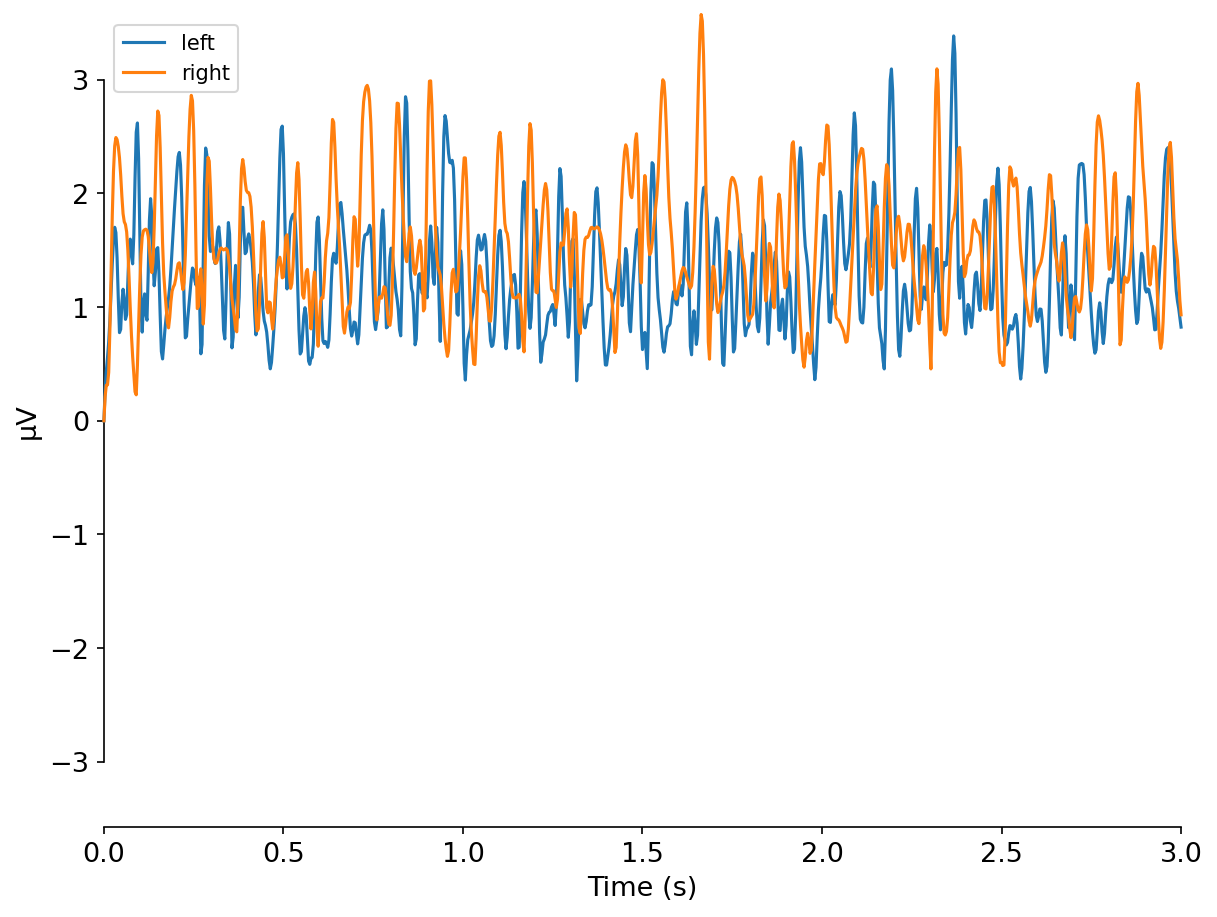

Loading file #3/4
Extracting EDF parameters from /content/drive/MyDrive/data/Mi Game/03_09_26_mi_omer_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 291599  =      0.000 ...   971.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-09 12:05:04 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
Filtering raw dat

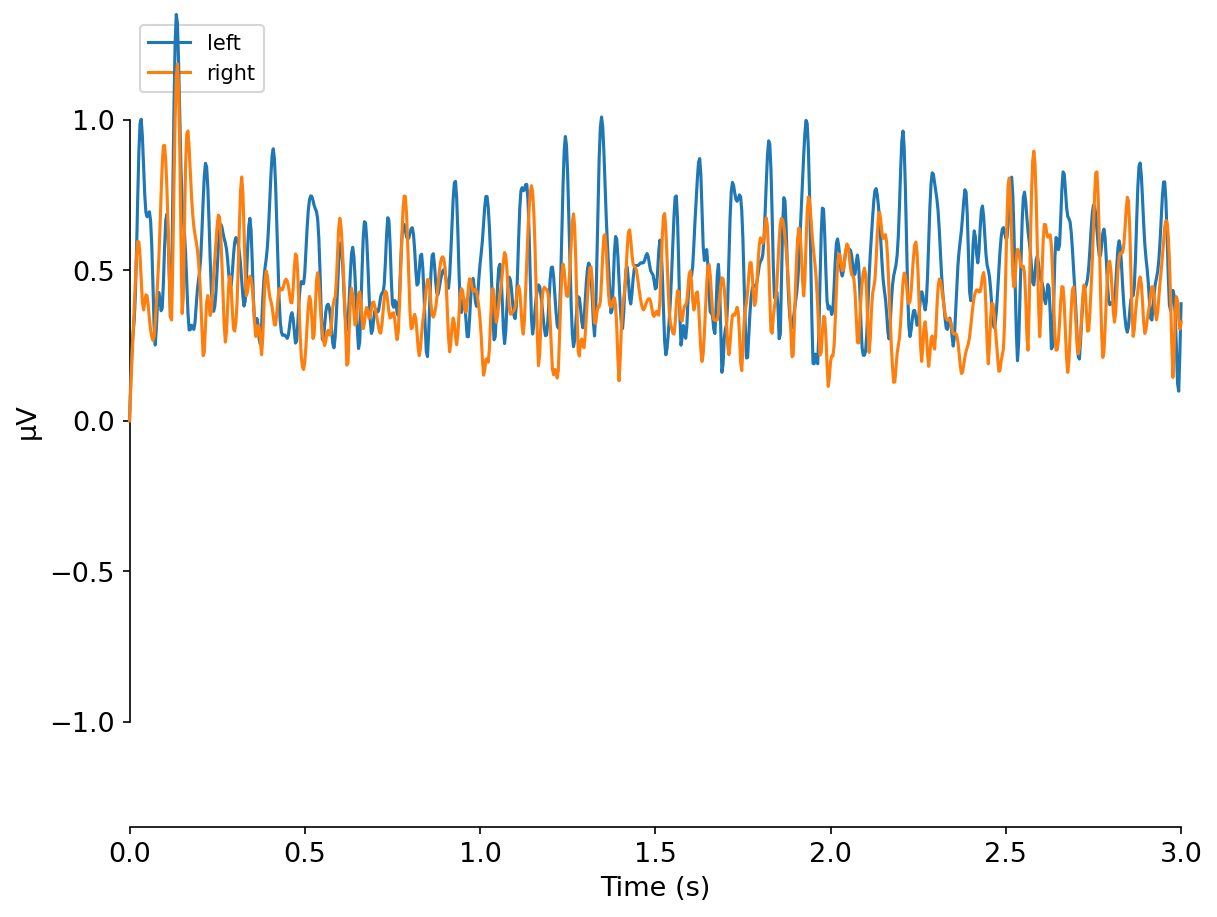

Loading file #4/4
Extracting EDF parameters from /content/drive/MyDrive/data/Mi Game/04_6_26_andy_mi_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 293399  =      0.000 ...   977.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-04-06 13:29:16 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
Filtering raw data

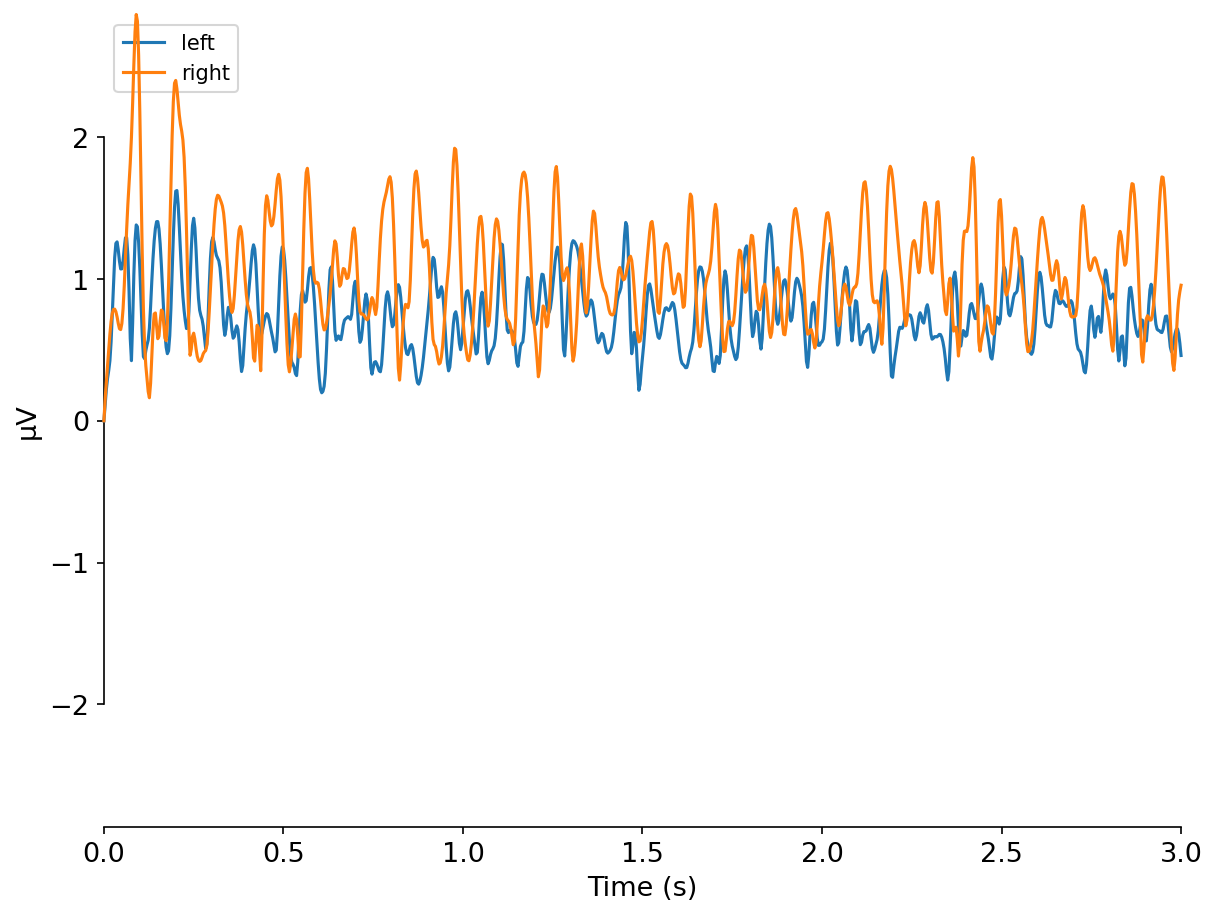

Shape of EEG data (num_trials, num_channels, epoch_len): (400, 7, 900)
Shape of labels array (num_trials,): (400,)
Shape of groups array (num_trials,): (400,)
Dataset label counts:
[['left' '200']
 ['right' '200']]
Dataset groups counts:
[[  0 100]
 [  1 100]
 [  2 100]
 [  3 100]]


In [21]:
import numpy as np
X = []
y = []
groups = []
total_len = len(data_files)
for i, data_file in enumerate(data_files):
  print(f"Loading file #{i+1}/{total_len}")
  datum, label = load_raw_edf(data_file)
  X.append(datum)
  y.append(label)
  groups.extend([i]*datum.shape[0])
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)
groups = np.array(groups)
print(f"Shape of EEG data (num_trials, num_channels, epoch_len): {X.shape}")
print(f"Shape of labels array (num_trials,): {y.shape}")
print(f"Shape of groups array (num_trials,): {groups.shape}")
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)
unique_groups, counts = np.unique(groups,return_counts=True)
print("Dataset groups counts:")
print(np.asarray((unique_groups, counts)).T)

In [22]:
y = [0 if lab == 'left' else 1 for lab in y]
y = np.array(y)
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts:
[[  0 200]
 [  1 200]]


In [23]:
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
### Within-Session Classification ###

def _make_classifier() -> Pipeline:
    return Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace(metric="riemann")),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis()),
    ])

# X: shape (num_samples, num_channels, window_len)
# y: shape (num_samples,)
# groups: shape (num_samples,) -> session id for each sample

session_scores = {}
all_session_means = []

unique_sessions = np.unique(groups)

for session_id in unique_sessions:
    session_mask = groups == session_id
    X_session = X[session_mask]
    y_session = y[session_mask]

    # Skip sessions that cannot support LOO classification
    if len(np.unique(y_session)) < 2:
        print(f"Session {session_id}: skipped (only one class present)")
        continue

    if len(y_session) < 2:
        print(f"Session {session_id}: skipped (fewer than 2 samples)")
        continue

    scores = cross_val_score(
        _make_classifier(),
        X_session,
        y_session,
        cv=LeaveOneOut(),
        scoring="accuracy",
        n_jobs=-1,
    )

    session_mean = scores.mean()
    session_std = scores.std()

    session_scores[session_id] = {
        "fold_scores": scores,
        "mean": session_mean,
        "std": session_std,
        "n_samples": len(y_session),
    }
    all_session_means.append(session_mean)

print("Results by session:")
for session_id in unique_sessions:
    if session_id not in session_scores:
        continue
    result = session_scores[session_id]
    print(
        f"  Session {session_id}: "
        f"accuracy={result['mean']:.3f} +/- {result['std']:.3f} "
        f"(n={result['n_samples']})"
    )

if all_session_means:
    print(f"\nAverage across sessions: {np.mean(all_session_means):.3f}")
    print(f"Std across sessions:     {np.std(all_session_means):.3f}")
else:
    print("\nNo valid sessions were evaluated.")

Results by session:
  Session 0: accuracy=0.710 +/- 0.454 (n=100)
  Session 1: accuracy=0.910 +/- 0.286 (n=100)
  Session 2: accuracy=0.590 +/- 0.492 (n=100)
  Session 3: accuracy=0.690 +/- 0.462 (n=100)

Average across sessions: 0.725
Std across sessions:     0.116


In [24]:
import sys
import mne
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_score, LeaveOneOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

### Cross Session/Participant classification ###

def _make_classifier() -> Pipeline:
    return Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace(metric="riemann")),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis()),
    ])
scores = cross_val_score(_make_classifier(), X, y,cv=LeaveOneGroupOut(), groups=groups, scoring="accuracy")

print(f"Results:")
for pid, score in enumerate(scores):
    print(f"Fold #{pid}: accuracy={score:.3f}")
print(f"\n  Mean: {scores.mean():.3f} +/- {scores.std():.3f}")

Results:
Fold #0: accuracy=0.690
Fold #1: accuracy=0.700
Fold #2: accuracy=0.500
Fold #3: accuracy=0.560

  Mean: 0.613 +/- 0.085


## Evaluation Figures

ROC-AUC, Confusion Matrices, MCC, ITR, and CSP Spatial Patterns.

In [25]:
### Compute all predictions (reused by all figures below) ###
from sklearn.model_selection import cross_val_predict, LeaveOneOut, LeaveOneGroupOut
from sklearn.metrics import roc_curve, auc, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

# --- Within-session predictions (LOO) ---
within_results = {}
for session_id in sorted(unique_sessions):
    mask = groups == session_id
    X_s, y_s = X[mask], y[mask]
    if len(np.unique(y_s)) < 2:
        continue
    y_prob = cross_val_predict(
        _make_classifier(), X_s, y_s,
        cv=LeaveOneOut(), method='predict_proba', n_jobs=-1
    )
    y_pred = (y_prob[:, 1] >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_s, y_prob[:, 1])
    within_results[session_id] = {
        'y_true': y_s, 'y_pred': y_pred, 'y_prob': y_prob,
        'fpr': fpr, 'tpr': tpr,
        'auc': auc(fpr, tpr),
        'mcc': matthews_corrcoef(y_s, y_pred),
        'acc': session_scores[session_id]['mean'],
    }

# --- Cross-session predictions (LOGO) ---
y_prob_cross = cross_val_predict(
    _make_classifier(), X, y,
    cv=LeaveOneGroupOut(), groups=groups, method='predict_proba', n_jobs=-1
)
y_pred_cross = (y_prob_cross[:, 1] >= 0.5).astype(int)

cross_results = {}
for session_id in sorted(unique_sessions):
    mask = groups == session_id
    fpr, tpr, _ = roc_curve(y[mask], y_prob_cross[mask, 1])
    cross_results[session_id] = {
        'y_true': y[mask], 'y_pred': y_pred_cross[mask],
        'fpr': fpr, 'tpr': tpr,
        'auc': auc(fpr, tpr),
        'mcc': matthews_corrcoef(y[mask], y_pred_cross[mask]),
        'acc': scores[int(session_id)],
    }

# Overall cross-session
fpr_all, tpr_all, _ = roc_curve(y, y_prob_cross[:, 1])
cross_overall = {
    'fpr': fpr_all, 'tpr': tpr_all,
    'auc': auc(fpr_all, tpr_all),
    'mcc': matthews_corrcoef(y, y_pred_cross),
    'acc': scores.mean(),
}
print("Predictions computed.")

Predictions computed.


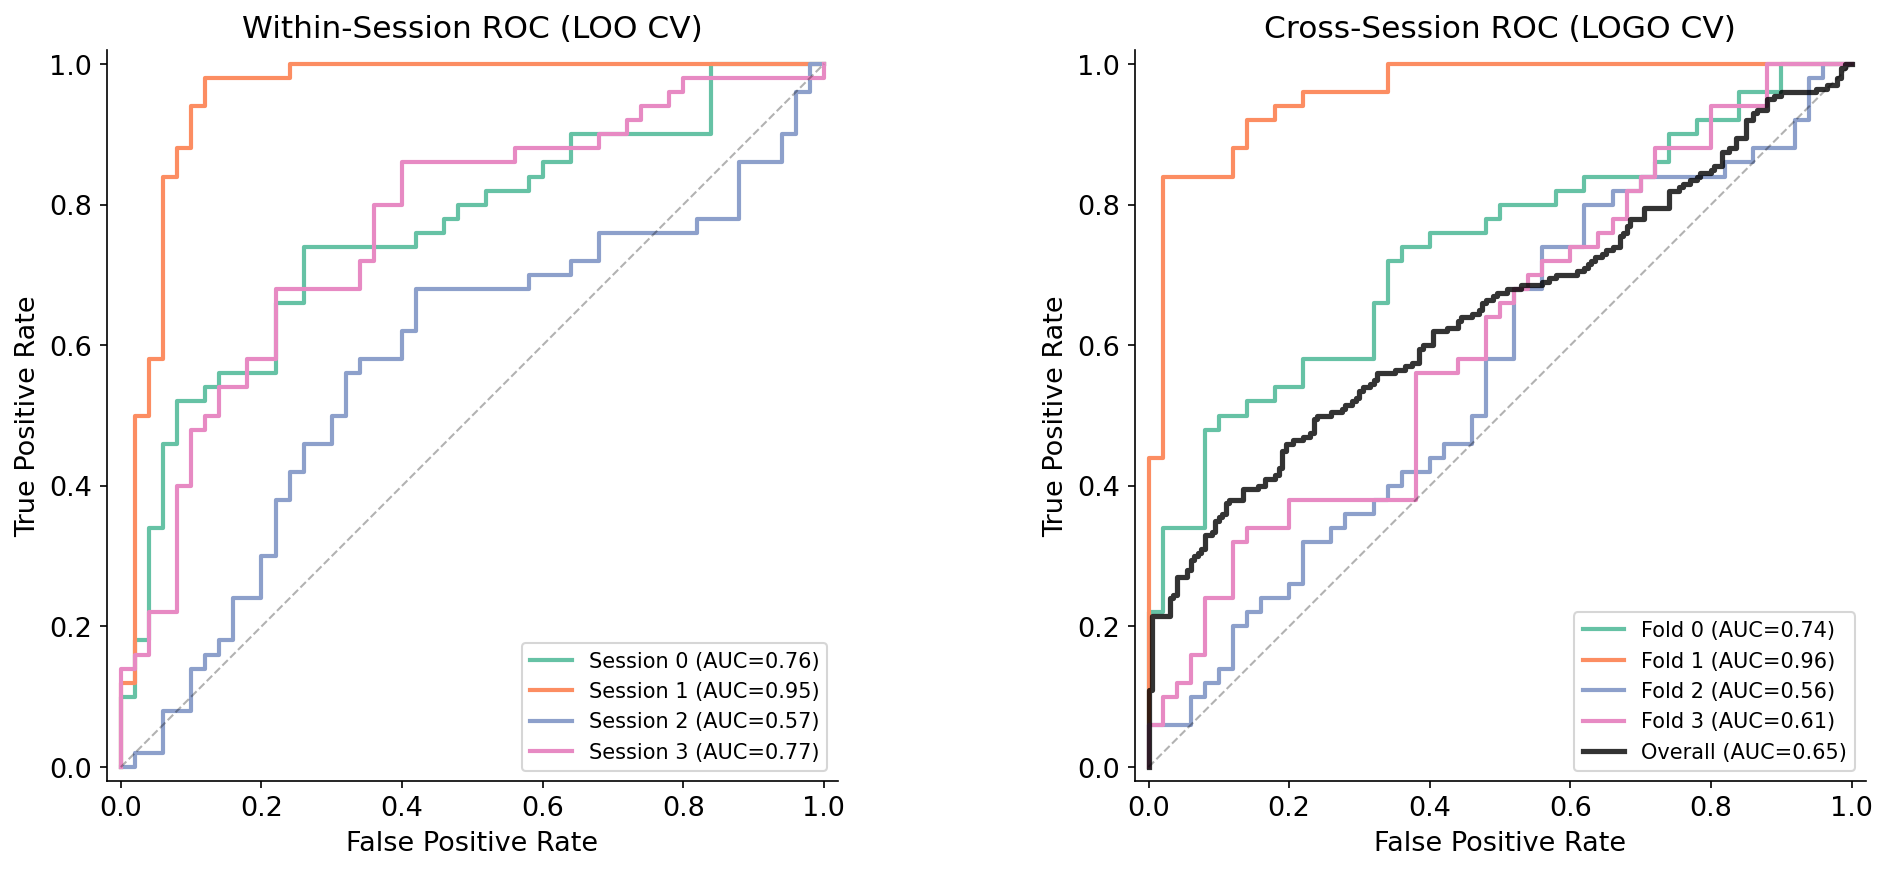

In [33]:
### Figure 1: ROC-AUC Curves ###

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.Set2.colors

# Within-session
for i, (sid, r) in enumerate(within_results.items()):
    ax1.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
             label=f'Session {int(sid)} (AUC={r["auc"]:.2f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Within-Session ROC (LOO CV)')
ax1.legend(loc='lower right')
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.set_aspect('equal')

# Cross-session
for i, (sid, r) in enumerate(cross_results.items()):
    ax2.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
             label=f'Fold {int(sid)} (AUC={r["auc"]:.2f})')
ax2.plot(cross_overall['fpr'], cross_overall['tpr'], 'k-', lw=2.5, alpha=0.8,
         label=f'Overall (AUC={cross_overall["auc"]:.2f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Cross-Session ROC (LOGO CV)')
ax2.legend(loc='lower right')
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])
ax2.set_aspect('equal')

fig.tight_layout()
plt.show()

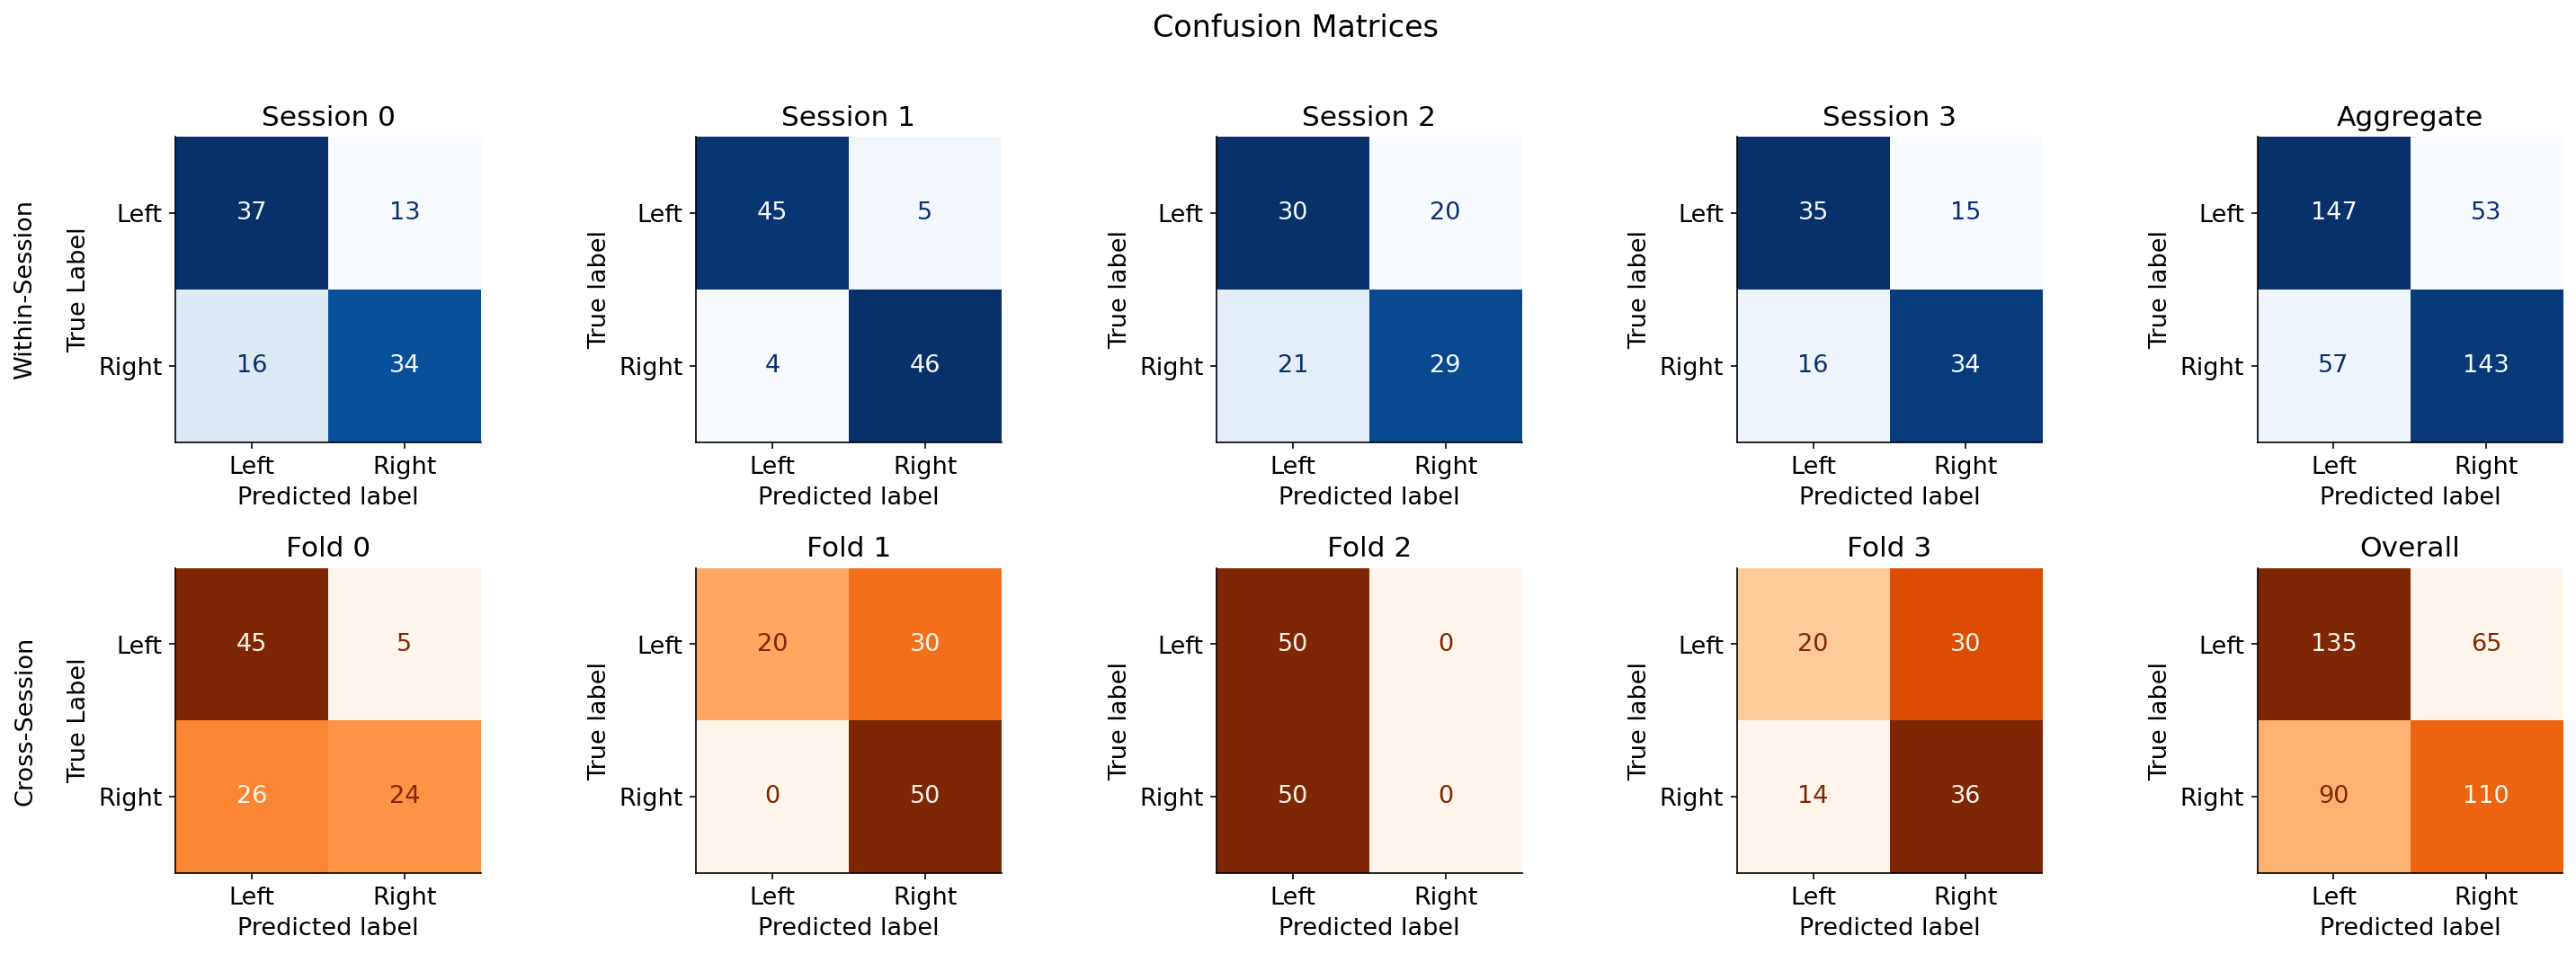

In [32]:
### Figure 2: Confusion Matrices ###
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ['Left', 'Right']
n_sess = len(unique_sessions)
fig, axes = plt.subplots(2, n_sess + 1, figsize=(4 * (n_sess + 1), 7))

# Row 0: Within-session
all_yt, all_yp = [], []
for idx, sid in enumerate(sorted(within_results.keys())):
    r = within_results[sid]
    all_yt.extend(r['y_true']); all_yp.extend(r['y_pred'])
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[0, idx], cmap='Blues', colorbar=False, values_format='d')
    axes[0, idx].set_title(f'Session {int(sid)}')

cm_agg = confusion_matrix(all_yt, all_yp)
ConfusionMatrixDisplay(cm_agg, display_labels=class_names).plot(
    ax=axes[0, n_sess], cmap='Blues', colorbar=False, values_format='d')
axes[0, n_sess].set_title('Aggregate')

# Row 1: Cross-session
for idx, sid in enumerate(sorted(cross_results.keys())):
    r = cross_results[sid]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[1, idx], cmap='Oranges', colorbar=False, values_format='d')
    axes[1, idx].set_title(f'Fold {int(sid)}')

cm_all = confusion_matrix(y, y_pred_cross)
ConfusionMatrixDisplay(cm_all, display_labels=class_names).plot(
    ax=axes[1, n_sess], cmap='Oranges', colorbar=False, values_format='d')
axes[1, n_sess].set_title('Overall')

axes[0, 0].set_ylabel('Within-Session\n\nTrue Label')
axes[1, 0].set_ylabel('Cross-Session\n\nTrue Label')
fig.suptitle('Confusion Matrices', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

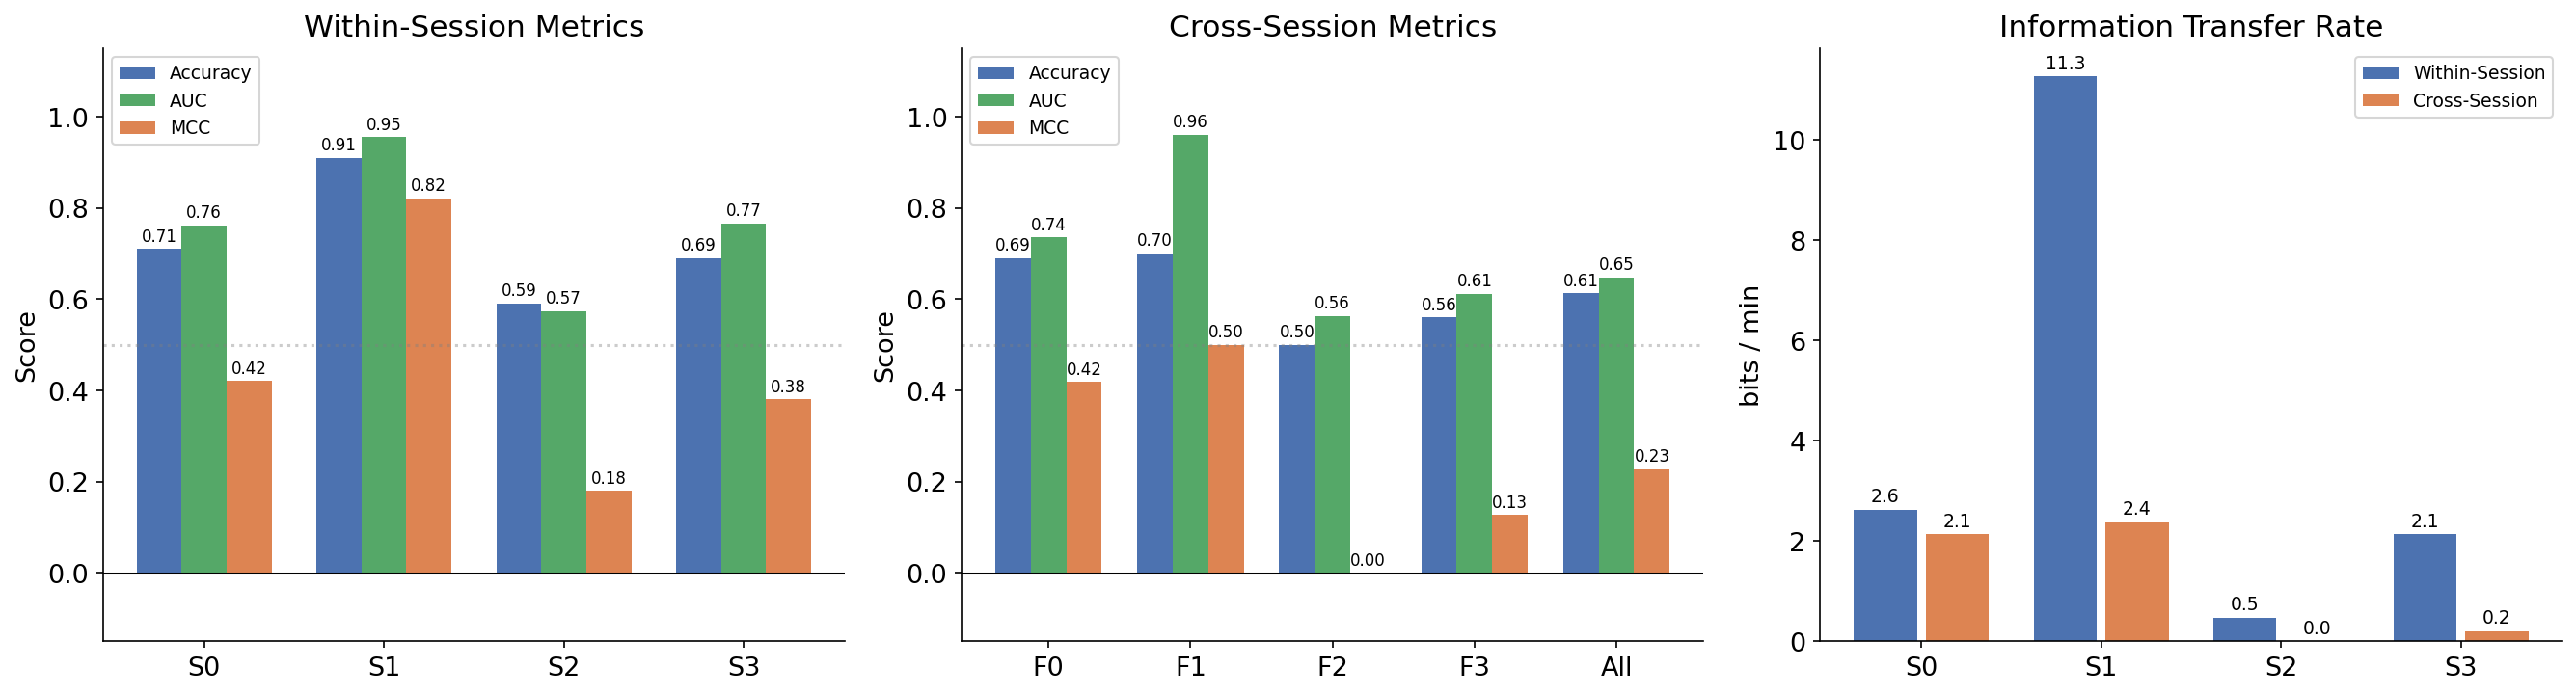

                Acc    AUC    MCC      ITR
------------------------------------------
  Within S0  0.710  0.761  0.421    2.63 b/m
  Within S1  0.910  0.955  0.820   11.27 b/m
  Within S2  0.590  0.574  0.180    0.47 b/m
  Within S3  0.690  0.766  0.380    2.14 b/m

  Cross  F0  0.690  0.735  0.419    2.14 b/m
  Cross  F1  0.700  0.960  0.500    2.37 b/m
  Cross  F2  0.500  0.563  0.000    0.00 b/m
  Cross  F3  0.560  0.612  0.127    0.21 b/m
  Cross All  0.613  0.648  0.227    0.74 b/m


In [30]:
### Figure 3: Metrics Summary (Accuracy, AUC, MCC) + ITR ###

def compute_itr(n_classes, accuracy, trial_duration_s):
    """Wolpaw ITR: bits/min."""
    P = np.clip(accuracy, 1e-10, 1 - 1e-10)
    N = n_classes
    if P <= 1.0 / N:
        return 0.0
    bits = np.log2(N) + P * np.log2(P) + (1 - P) * np.log2((1 - P) / (N - 1))
    return bits * (60.0 / trial_duration_s)

trial_dur = 3.0  # epoch length in seconds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_metric = {'Accuracy': '#4C72B0', 'AUC': '#55A868', 'MCC': '#DD8452'}
key_map = {'Accuracy': 'acc', 'AUC': 'auc', 'MCC': 'mcc'}

# --- Panel A: Within-session metrics ---
sids = sorted(within_results.keys())
labels_w = [f'S{int(s)}' for s in sids]
x = np.arange(len(sids))
w = 0.25

for i, (metric, color) in enumerate(colors_metric.items()):
    key = key_map[metric]
    vals = [within_results[s][key] for s in sids]
    bars = axes[0].bar(x + i * w - w, vals, w, label=metric, color=color)
    axes[0].bar_label(bars, fmt='%.2f', fontsize=8, padding=2)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_w)
axes[0].set_ylabel('Score')
axes[0].set_title('Within-Session Metrics')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_ylim([-0.15, 1.15])
axes[0].axhline(0.5, color='gray', ls=':', alpha=0.4)
axes[0].axhline(0, color='k', lw=0.5)

# --- Panel B: Cross-session metrics ---
labels_c = [f'F{int(s)}' for s in sorted(cross_results.keys())] + ['All']
x2 = np.arange(len(labels_c))

for i, (metric, color) in enumerate(colors_metric.items()):
    key = key_map[metric]
    vals = [cross_results[s][key] for s in sorted(cross_results.keys())] + [cross_overall[key]]
    bars = axes[1].bar(x2 + i * w - w, vals, w, label=metric, color=color)
    axes[1].bar_label(bars, fmt='%.2f', fontsize=8, padding=2)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels_c)
axes[1].set_ylabel('Score')
axes[1].set_title('Cross-Session Metrics')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].set_ylim([-0.15, 1.15])
axes[1].axhline(0.5, color='gray', ls=':', alpha=0.4)
axes[1].axhline(0, color='k', lw=0.5)

# --- Panel C: ITR ---
itrs_w = [compute_itr(2, within_results[s]['acc'], trial_dur) for s in sids]
itrs_c = [compute_itr(2, cross_results[s]['acc'], trial_dur) for s in sorted(cross_results.keys())]
itr_overall = compute_itr(2, cross_overall['acc'], trial_dur)

x3 = np.arange(len(sids))
bars_w = axes[2].bar(x3 - 0.2, itrs_w, 0.35, label='Within-Session', color='#4C72B0')
bars_c = axes[2].bar(x3 + 0.2, itrs_c, 0.35, label='Cross-Session', color='#DD8452')
axes[2].bar_label(bars_w, fmt='%.1f', fontsize=9, padding=2)
axes[2].bar_label(bars_c, fmt='%.1f', fontsize=9, padding=2)
axes[2].set_xticks(x3)
axes[2].set_xticklabels(labels_w)
axes[2].set_ylabel('bits / min')
axes[2].set_title('Information Transfer Rate')
axes[2].legend(fontsize=9)

fig.tight_layout()
plt.show()

# Print summary table
print(f"{'':>12s} {'Acc':>6s} {'AUC':>6s} {'MCC':>6s} {'ITR':>8s}")
print("-" * 42)
for s in sids:
    r = within_results[s]
    itr = compute_itr(2, r['acc'], trial_dur)
    print(f"  Within S{int(s):d}  {r['acc']:.3f}  {r['auc']:.3f}  {r['mcc']:.3f}  {itr:6.2f} b/m")
print()
for s in sorted(cross_results.keys()):
    r = cross_results[s]
    itr = compute_itr(2, r['acc'], trial_dur)
    print(f"  Cross  F{int(s):d}  {r['acc']:.3f}  {r['auc']:.3f}  {r['mcc']:.3f}  {itr:6.2f} b/m")
print(f"  Cross All  {cross_overall['acc']:.3f}  {cross_overall['auc']:.3f}  {cross_overall['mcc']:.3f}  {itr_overall:6.2f} b/m")

Computing rank from data with rank=None
    Using tolerance 9.4e-06 (2.2e-16 eps * 7 dim * 6.1e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.3e-05 (2.2e-16 eps * 7 dim * 8.4e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.2e-06 (2.2e-16 eps * 7 dim * 3.4e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using EMPIRICAL
Done.
Estim

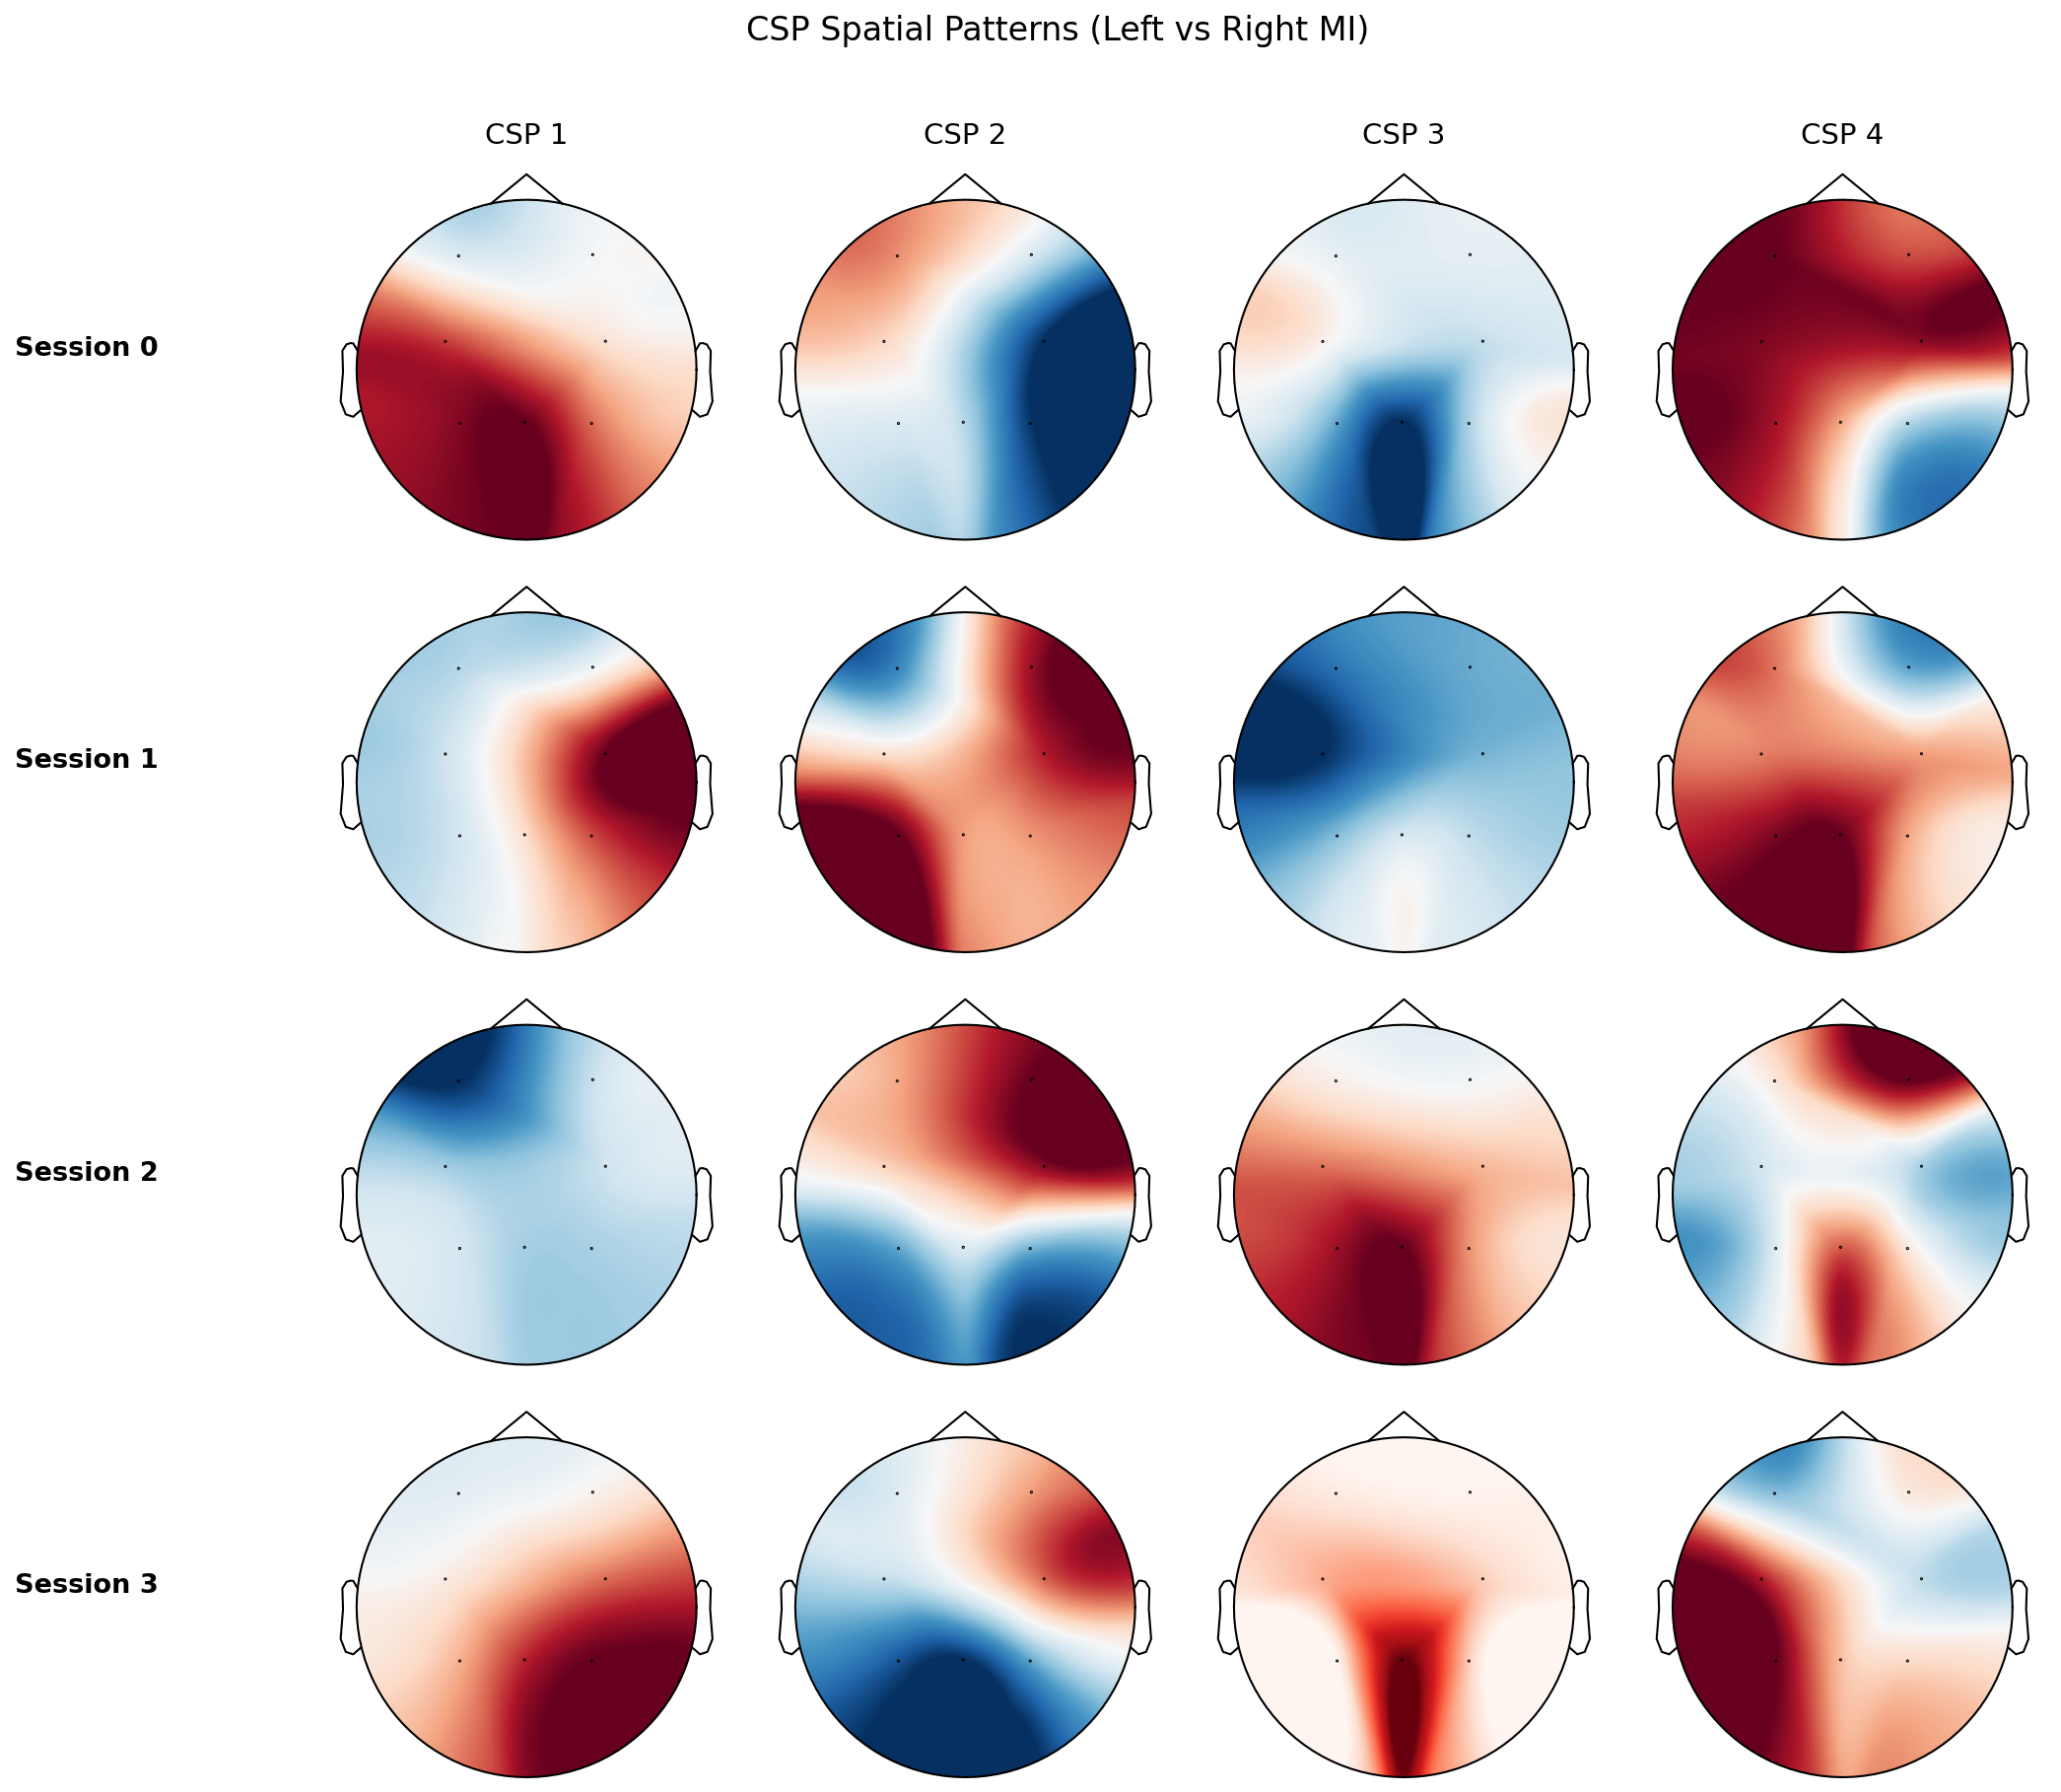

CSP 1-2: maximize variance for one class | CSP 3-4: maximize for the other
Look for lateralized patterns over C3/C4 (sensorimotor cortex)


In [31]:
### Figure 4: CSP Spatial Topographic Maps ###
from mne.decoding import CSP as MNE_CSP

# Channel order in X (from load_raw_edf picks):
# ['EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz']
ch_names_std = ['F4', 'C4', 'P4', 'P3', 'C3', 'F3', 'Pz']
info_topo = mne.create_info(ch_names_std, sfreq=300, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info_topo.set_montage(montage)

n_components = 4
n_sessions = len(unique_sessions)
fig, axes = plt.subplots(n_sessions, n_components, figsize=(3.5 * n_components, 3 * n_sessions))

for idx, session_id in enumerate(sorted(unique_sessions)):
    mask = groups == session_id
    X_s, y_s = X[mask], y[mask]

    csp = MNE_CSP(n_components=n_components, reg=None, log=True)
    csp.fit(X_s, y_s)

    patterns = csp.patterns_[:n_components]
    for j in range(n_components):
        mne.viz.plot_topomap(
            patterns[j], info_topo, axes=axes[idx, j],
            show=False, contours=0
        )
        if idx == 0:
            axes[idx, j].set_title(f'CSP {j+1}', fontsize=14)

    axes[idx, 0].text(
        -0.4, 0.5, f'Session {int(session_id)}',
        transform=axes[idx, 0].transAxes,
        fontsize=13, va='center', ha='right', fontweight='bold'
    )

fig.suptitle('CSP Spatial Patterns (Left vs Right MI)', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

print("CSP 1-2: maximize variance for one class | CSP 3-4: maximize for the other")
print("Look for lateralized patterns over C3/C4 (sensorimotor cortex)")